# Import Library

In [40]:
# import some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import json
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

seed = 42
random.seed(seed)
np.random.seed(seed)

warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
# path dataset
path = 'gadai.xlsx'

# read dataset
df = pd.read_excel("gadai.xlsx")
# drop index pertama
df.drop(0, inplace=True)
# reset index
df.reset_index(drop=True, inplace=True)
df

,no_bon,tgl_trx,kd_outlet,jid,id_pel,nama_pel,alamat,notel,jenis,type,sn,besar,tenor,tempo,total_tebus,ket_id,ket_sn,re,id_admin
0,1.0,2023-08-23,OD04,KTP,3.276031e+15,ANDRA GUSTAMA,PSP,8.570414e+10,HP,OPPO A5,8014/8006,400000.0,30.0,2023-09-22,460000.0,lama,baru,HERMAN,ENC07
1,3.0,2023-08-23,OD04,KTP,3.276036e+15,MARNIH,PSP 001/004,8.953917e+11,HP,REDMI 9A,50836,350000.0,7.0,2023-08-30,367500.0,baru,baru,HERMAN,ENC07
2,5.0,2023-08-23,OD04,KTP,3.276062e+15,ABDUL RAHMAN MASTUR,JALAN JOHOR 003/003,8.128808e+10,HP,REALME C11,76091,400000.0,30.0,2023-09-22,460000.0,lama,baru,RIANI GEA,ENC07
3,2.0,2025-02-03,OD03,KTP,3.201371e+15,SUKAMTO INDRIANSYAH,KP KALISUREN 002/003 TAJURHALANG,1.106810e+05,HP,GALAXY A14,212363,900000.0,14.0,2025-02-17,990000.0,lama,lama,FIRKAS,ENC06
4,4.0,2025-02-04,OD03,KTP,3.201371e+15,SUKAMTO INDRIANSYAH,KP KALISUREN 002/003 TAJURHALANG,1.106810e+05,HP,GALAXY A15,95853,1500000.0,30.0,2025-03-06,1725000.0,lama,baru,FIRKAS,ENC06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,NaN,2024-06-23,OD04,KTP,3.276072e+15,PAMUJI,LIO 003/007,8.952754e+10,HP,INFINIX SMART 6 HD,3567,300000.0,7.0,2024-06-30,315000.0,lama,baru,DAVA,ENC07
8096,NaN,2024-06-23,OD04,KTP,3.276035e+15,KIKI NANDAWATI,KP.KEKUPU 002/006,8.952080e+10,HP,OPPO A18,7268,800000.0,7.0,2024-06-30,840000.0,lama,baru,DAVA,ENC07
8097,NaN,2024-06-29,OD04,KTP,3.276047e+15,DEWI SETIAWATI,JL.KOMA,8.954039e+11,HP,INFINIX SMART 8,3544,100000.0,7.0,2024-07-06,105000.0,lama,lama,DAVA,ENC07
8098,NaN,2024-06-29,OD04,KTP,3.276016e+15,JIHAN ALFAQIAH JAWAS,JL.KALIKI,8.569706e+10,HP,"SM, GALAXY M12",3543,300000.0,7.0,2024-07-06,315000.0,lama,lama,DAVA,ENC07


# Data Understanding

In [3]:
# cek nama col
df.columns

Index(['no_bon', ' tgl_trx', ' kd_outlet', ' jid', ' id_pel', ' nama_pel',
       ' alamat', ' notel', ' jenis', ' type', ' sn', ' besar', ' tenor',
       ' tempo', ' total_tebus', ' ket_id', ' ket_sn', ' re', ' id_admin'],
      dtype='object')

karena nama kolom blm rapi (ada spasi) maka akan saya rapihkan

In [4]:
# hapus spasi
df.columns = df.columns.str.strip()
print("Cleaned column names:")
print(df.columns)

Cleaned column names:
Index(['no_bon', 'tgl_trx', 'kd_outlet', 'jid', 'id_pel', 'nama_pel', 'alamat',
       'notel', 'jenis', 'type', 'sn', 'besar', 'tenor', 'tempo',
       'total_tebus', 'ket_id', 'ket_sn', 're', 'id_admin'],
      dtype='object')


In [5]:
# shape
df.shape

(8100, 19)

In [6]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_bon       7005 non-null   float64       
 1   tgl_trx      8067 non-null   datetime64[ns]
 2   kd_outlet    8100 non-null   object        
 3   jid          8100 non-null   object        
 4   id_pel       8066 non-null   float64       
 5   nama_pel     8100 non-null   object        
 6   alamat       8100 non-null   object        
 7   notel        8065 non-null   float64       
 8   jenis        8100 non-null   object        
 9   type         8099 non-null   object        
 10  sn           8100 non-null   object        
 11  besar        8067 non-null   float64       
 12  tenor        8067 non-null   float64       
 13  tempo        8067 non-null   datetime64[ns]
 14  total_tebus  8067 non-null   float64       
 15  ket_id       8100 non-null   object        
 16  ket_sn

In [7]:
# descriptive statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
no_bon,7005.0,52796.413562,1.0,11546.0,86795.0,90095.0,926866.0,42608.86762
tgl_trx,8067,2024-06-28 18:26:33.157307648,2023-07-01 00:00:00,2023-12-28 00:00:00,2024-05-28 00:00:00,2024-12-30 00:00:00,2025-09-17 00:00:00,NaN
id_pel,8066.0,4883063954644130.0,10243.0,3201101701960007.0,3201335254955006.0,3201394504720004.0,3273276034701920256.0,62753680426348576.0
notel,8065.0,120279310496103.640625,0.0,0.0,81316682908.0,85813604505.0,88101047041895088.0,3251660587239327.5
besar,8067.0,518575.058882,100000.0,300000.0,500000.0,600000.0,3500000.0,280752.173992
tenor,8067.0,13.975456,7.0,7.0,7.0,14.0,30.0,9.189017
tempo,8067,2024-07-12 17:51:12.517664512,2023-07-08 00:00:00,2024-01-11 00:00:00,2024-06-11 00:00:00,2025-01-12 00:00:00,2025-10-17 00:00:00,NaN
total_tebus,8067.0,564660.74749,105000.0,330000.0,525000.0,690000.0,4025000.0,310568.598435


In [8]:
# list kolom fitur nums dan cats
nums = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cats = df.select_dtypes(include=['object']).columns.tolist()

# cek kol
print('Jumlah Kolom Numerik :', len(nums))
print('Kolom Numerik :', nums)

print('\nJumlah Kolom Kategorik :', len(cats))
print('Kolom Kategorik :', cats)

Jumlah Kolom Numerik : 6
Kolom Numerik : ['no_bon', 'id_pel', 'notel', 'besar', 'tenor', 'total_tebus']

Jumlah Kolom Kategorik : 11
Kolom Kategorik : ['kd_outlet', 'jid', 'nama_pel', 'alamat', 'jenis', 'type', 'sn', 'ket_id', 'ket_sn', 're', 'id_admin']


# Data Preprocessing

In [9]:
df.head()

,no_bon,tgl_trx,kd_outlet,jid,id_pel,nama_pel,alamat,notel,jenis,type,sn,besar,tenor,tempo,total_tebus,ket_id,ket_sn,re,id_admin
0,1.0,2023-08-23,OD04,KTP,3.276031e+15,ANDRA GUSTAMA,PSP,8.570414e+10,HP,OPPO A5,8014/8006,400000.0,30.0,2023-09-22,460000.0,lama,baru,HERMAN,ENC07
1,3.0,2023-08-23,OD04,KTP,3.276036e+15,MARNIH,PSP 001/004,8.953917e+11,HP,REDMI 9A,50836,350000.0,7.0,2023-08-30,367500.0,baru,baru,HERMAN,ENC07
2,5.0,2023-08-23,OD04,KTP,3.276062e+15,ABDUL RAHMAN MASTUR,JALAN JOHOR 003/003,8.128808e+10,HP,REALME C11,76091,400000.0,30.0,2023-09-22,460000.0,lama,baru,RIANI GEA,ENC07
3,2.0,2025-02-03,OD03,KTP,3.201371e+15,SUKAMTO INDRIANSYAH,KP KALISUREN 002/003 TAJURHALANG,1.106810e+05,HP,GALAXY A14,212363,900000.0,14.0,2025-02-17,990000.0,lama,lama,FIRKAS,ENC06
4,4.0,2025-02-04,OD03,KTP,3.201371e+15,SUKAMTO INDRIANSYAH,KP KALISUREN 002/003 TAJURHALANG,1.106810e+05,HP,GALAXY A15,95853,1500000.0,30.0,2025-03-06,1725000.0,lama,baru,FIRKAS,ENC06


In [10]:
# drop kolom yg tidak memberikan informasi
list_drop_col = [
    'no_bon', 'tgl_trx', 'id_pel', 'nama_pel', 'alamat', 'notel', 'sn', 're', 'tempo', 'kd_outlet', 'ket_id', 'ket_sn', 'id_admin', 'jid'
]

df.drop(list_drop_col, axis=1, inplace=True)
df.head()

,jenis,type,besar,tenor,total_tebus
0,HP,OPPO A5,400000.0,30.0,460000.0
1,HP,REDMI 9A,350000.0,7.0,367500.0
2,HP,REALME C11,400000.0,30.0,460000.0
3,HP,GALAXY A14,900000.0,14.0,990000.0
4,HP,GALAXY A15,1500000.0,30.0,1725000.0


In [11]:
# cek missing values
print('Missing values per kolom:')
print(df.isna().sum())

Missing values per kolom:
jenis           0
type            1
besar          33
tenor          33
total_tebus    33
dtype: int64


In [12]:
# cek outlier
def cek_outlier(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      continue
    else:
      q1 = df[col].quantile(0.25)
      q3 = df[col].quantile(0.75)
      iqr = q3 - q1

      lower_bound = q1 - (1.5 * iqr)
      upper_bound = q3 + (1.5 * iqr)

      outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

      if not outliers.empty:
        print(f"Kolom {col} memiliki outlier")
        print(f"Jumlah outlier: {len(outliers)}")
      else:
        print(f"Kolom {col} tidak memiliki outlier")

cek_outlier(df)

Kolom besar memiliki outlier
Jumlah outlier: 336
Kolom tenor memiliki outlier
Jumlah outlier: 1847
Kolom total_tebus memiliki outlier
Jumlah outlier: 310


setelah di cek missing values dan outlier, maka strategi impute missing values dmn untuk kol kategorik menggunakan modus sedangkan kol numerik menggunakan median (lebih robust terhadap outlier)

In [13]:
# impute missing value (kategorik = modus)
df['type'] = df['type'].fillna(df['type'].mode()[0])

# (numeric = median)
list_num = ['tenor', 'total_tebus', 'besar']

for col in list_num:
  df[col] = df[col].fillna(df[col].median())

In [14]:
# cek missing values
df.isna().sum()

,0
jenis,0
type,0
besar,0
tenor,0
total_tebus,0


In [15]:
# cek shape setelah preprocessing
print('Shape setelah preprocessing:')
df.shape

Shape setelah preprocessing:


(8100, 5)

In [16]:
df.head()

,jenis,type,besar,tenor,total_tebus
0,HP,OPPO A5,400000.0,30.0,460000.0
1,HP,REDMI 9A,350000.0,7.0,367500.0
2,HP,REALME C11,400000.0,30.0,460000.0
3,HP,GALAXY A14,900000.0,14.0,990000.0
4,HP,GALAXY A15,1500000.0,30.0,1725000.0


In [17]:
# cek unik kol jenis
print("Nilai unik dalam kolom 'jenis':")
print(df['jenis'].unique())

Nilai unik dalam kolom 'jenis':
['HP' 'TV' 'LAPTOP' ' `jenis`' 'TAB' 'SPIKER' 'HPREDMI 9C' 'LAPTOP ' 'TV '
 'LAP LAPTOP' 'LAP TOP']


karena value di dalam kolom `jenis` inconsistent maka akan saya perbaiki terlebih dahulu sebelum ke EDA

In [18]:
# exclude value jenis
df = df[~df['jenis'].isin(['`JENIS`'])]

In [19]:
# convert ke string
df['jenis'] = df['jenis'].astype(str).str.upper().str.strip()

# define mapping
type_replacements = {
    'LAP LAPTOP': 'LAPTOP',
    'LAP TOP': 'LAPTOP',
    'TV ': 'TV',
    'HPREDMI 9C': 'HP'
}

df['jenis'] = df['jenis'].replace(type_replacements)

In [20]:
df

,jenis,type,besar,tenor,total_tebus
0,HP,OPPO A5,400000.0,30.0,460000.0
1,HP,REDMI 9A,350000.0,7.0,367500.0
2,HP,REALME C11,400000.0,30.0,460000.0
3,HP,GALAXY A14,900000.0,14.0,990000.0
4,HP,GALAXY A15,1500000.0,30.0,1725000.0
...,...,...,...,...,...
8095,HP,INFINIX SMART 6 HD,300000.0,7.0,315000.0
8096,HP,OPPO A18,800000.0,7.0,840000.0
8097,HP,INFINIX SMART 8,100000.0,7.0,105000.0
8098,HP,"SM, GALAXY M12",300000.0,7.0,315000.0


In [21]:
# cek lagi
print("Nilai unik dalam kolom 'jenis' setelah preprocessing:")
print(df['jenis'].unique())

Nilai unik dalam kolom 'jenis' setelah preprocessing:
['HP' 'TV' 'LAPTOP' '`JENIS`' 'TAB' 'SPIKER']


In [22]:
# cek nilai unik kol type
print("Total nilai unik dalam kolom 'type':")
print(df['type'].nunique())

Total nilai unik dalam kolom 'type':
1209


In [23]:
# cek counts untuk cek kategori langka
jenis_counts = df['jenis'].value_counts()

#rare_brands = brand_counts[brand_counts < 10].index
rare_jenis = jenis_counts[jenis_counts < 10].index

print('\nKategori langka untuk jenis:')
print(rare_jenis)


Kategori langka untuk jenis:
Index(['TAB', 'SPIKER'], dtype='object', name='jenis')


In [24]:
# hapus kategori '`JENIS`' dari var jenis
df = df[(~df['jenis'].isin(['`JENIS`']))]

In [25]:
df.head()

,jenis,type,besar,tenor,total_tebus
0,HP,OPPO A5,400000.0,30.0,460000.0
1,HP,REDMI 9A,350000.0,7.0,367500.0
2,HP,REALME C11,400000.0,30.0,460000.0
3,HP,GALAXY A14,900000.0,14.0,990000.0
4,HP,GALAXY A15,1500000.0,30.0,1725000.0


In [46]:
# mapping jenis -> list of type
jenis_to_type = (
    df.groupby('jenis')['type']
      .apply(lambda x: sorted(x.dropna().unique().tolist()))
      .to_dict()
)

# list jenis unik
jenis_options = sorted(list(jenis_to_type.keys()))

with open("options.json", "w") as f:
    json.dump(
        {
            "jenis_options": jenis_options,
            "jenis_to_type": jenis_to_type,
        },
        f
    )


In [60]:
# cek dataframe jenis untuk tiap tipe
unique_jenis = df['jenis'].unique()

hp_dfs = {}
for jenis_val in unique_jenis:
    filtered_df = df[df['jenis'] == jenis_val][['jenis', 'type']]
    hp_dfs[jenis_val] = filtered_df

# misal untuk jenis HP
hp_dfs['HP']

# uncomment (untuk filtered ke type)
# laptop_asus_types = hp_dfs['LAPTOP'][hp_dfs['LAPTOP']['type'].str.contains('ASUS', case=False, na=False)]
# print("Types containing 'ASUS' in LAPTOP category:")
# print(laptop_asus_types.head())

,jenis,type
0,HP,OPPO A5
1,HP,REDMI 9A
2,HP,REALME C11
3,HP,GALAXY A14
4,HP,GALAXY A15
...,...,...
8095,HP,INFINIX SMART 6 HD
8096,HP,OPPO A18
8097,HP,INFINIX SMART 8
8098,HP,"SM, GALAXY M12"


# Eksploratory Data Analysis

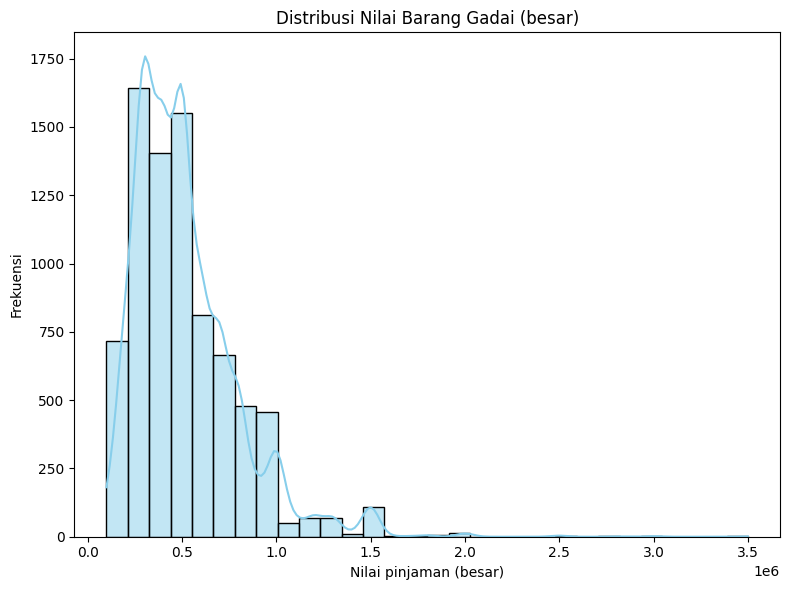

In [26]:
# distribusi target var (besar)
plt.figure(figsize=(8, 6))
sns.histplot(df["besar"], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribusi Nilai Barang Gadai (besar)")
plt.xlabel("Nilai pinjaman (besar)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

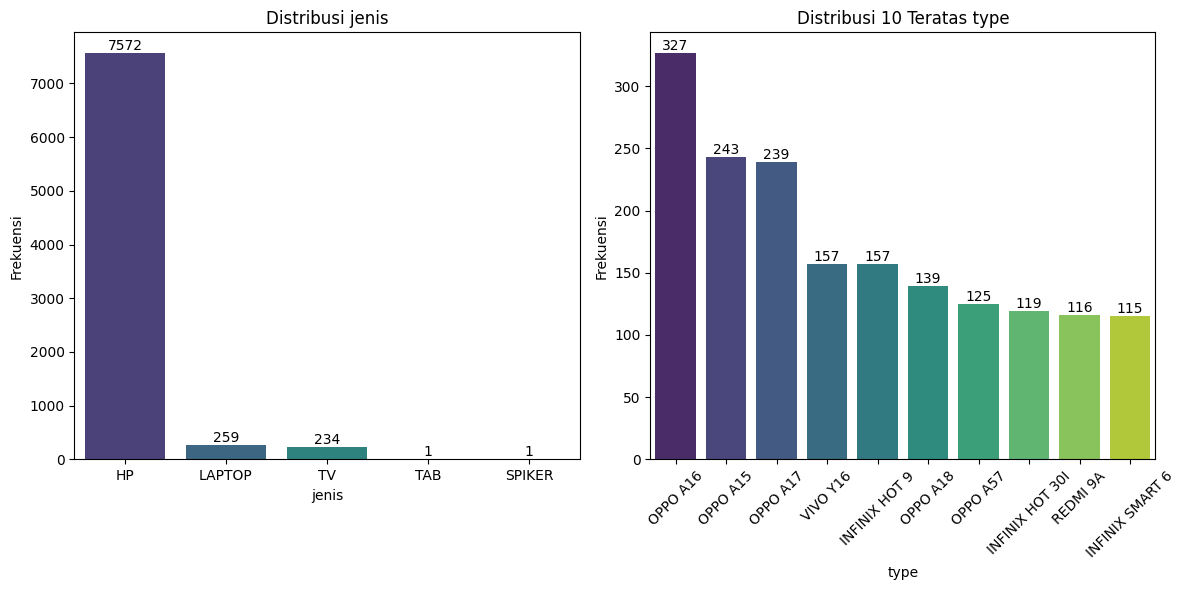

In [61]:
# visualisasi cat untuk kelas > 2
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for jenis
sns.countplot(x='jenis', data=df, ax=axes[0], palette='viridis', order=df['jenis'].value_counts().index)
axes[0].set_title('Distribusi jenis')
axes[0].set_xlabel('jenis')
axes[0].set_ylabel('Frekuensi')
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot for type
type_counts = df['type'].value_counts()
type_counts_10 = type_counts.sort_values(ascending=False).nlargest(10)
sns.barplot(x=type_counts_10.index, y=type_counts_10, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi 10 Teratas type')
axes[1].set_xlabel('type')
axes[1].set_ylabel('Frekuensi')
axes[1].tick_params(axis='x', rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

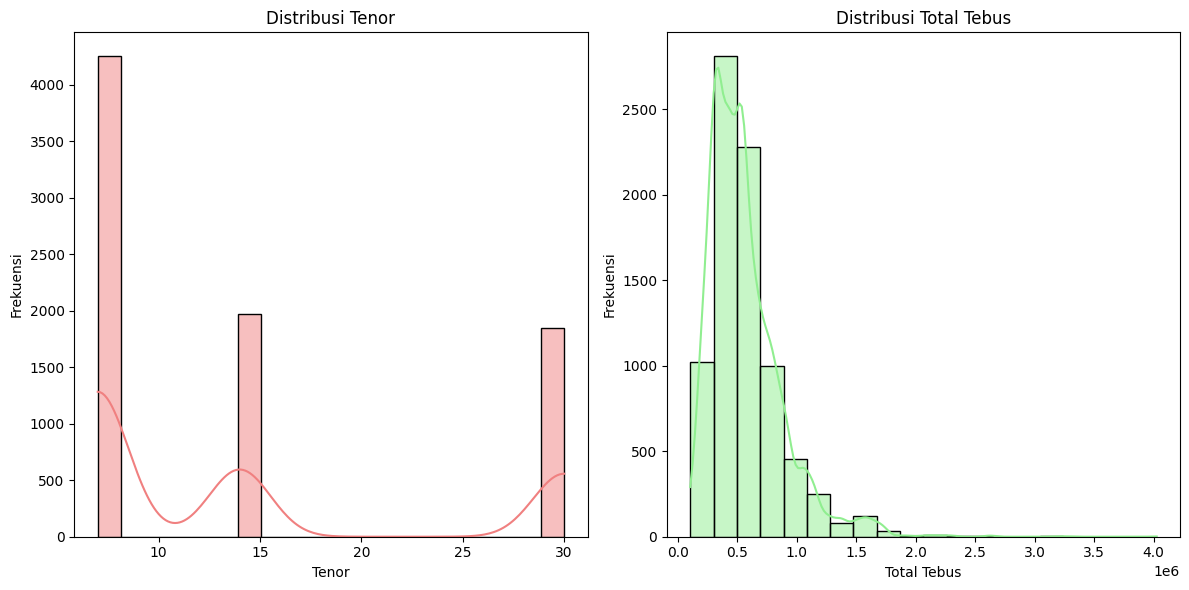

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histplot for tenor
sns.histplot(df['tenor'], bins=20, kde=True, color='lightcoral', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribusi Tenor')
axes[0].set_xlabel('Tenor')
axes[0].set_ylabel('Frekuensi')

# Histplot for total_tebus
sns.histplot(df['total_tebus'], bins=20, kde=True, color='lightgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribusi Total Tebus')
axes[1].set_xlabel('Total Tebus')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

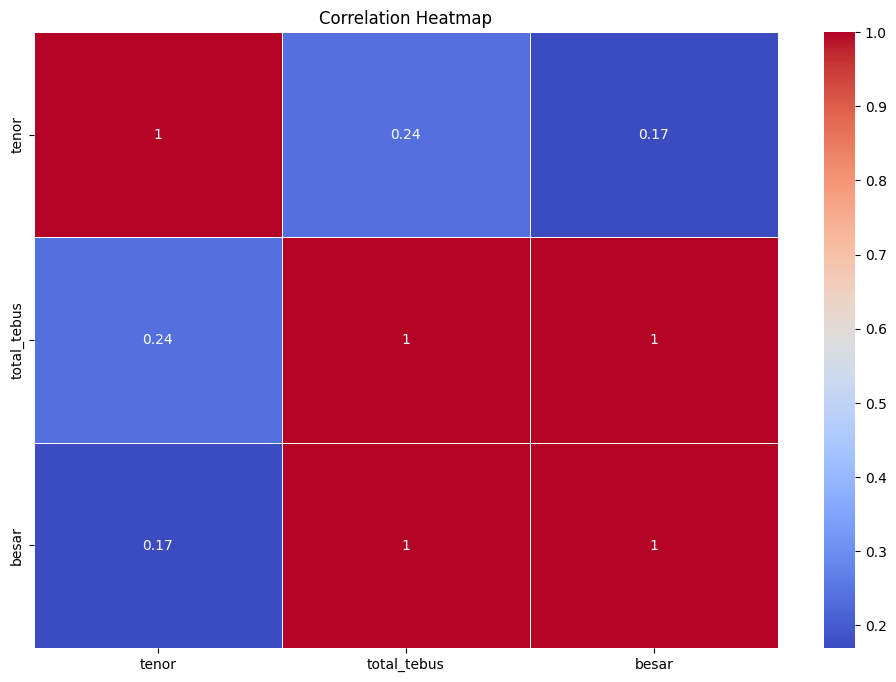

In [29]:
# heatmap corr
heatmap = ['tenor', 'total_tebus', 'besar']

plt.figure(figsize=(12,8))
sns.heatmap(df[heatmap].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

kalo dilihat dari heatmap diatas kolom `total_tebus` ddan `besar` memiliki korelasi yg sangat tinggi dan bisa dibilang ini ada kaitannya dengan target var yakni kolom `besar` maka akan di drop di modelling

# Data Modelling

In [30]:
# splitting data
exclude_col = ['besar', 'total_tebus']

X = df.drop(exclude_col, axis=1)
y = df['besar']

# cek col X
print('Kolom X:')
print(X.columns)

Kolom X:
Index(['jenis', 'type', 'tenor'], dtype='object')


In [31]:
# list fitur nums dan cat
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [32]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

# cek shape
print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)

Shape X_train: (6453, 3)
Shape X_test: (1614, 3)


In [33]:
# one hot encoding
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    drop="first"
)

# column transformer untuk col num dan cat
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [34]:
# feature selection
k_best = 'all'

feature_selector = SelectKBest(
    score_func=mutual_info_regression,
    k=k_best
)

In [35]:
# random forest
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
)

# pipeline
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("select", feature_selector),
        ("rf", rf),
    ]
)

pipeline.fit(X_train, y_train)

print("Training selesai!")

Training selesai!


# Model Evaluation

In [36]:
# evaluasi modekl
best_model = pipeline

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

def evaluate_regression(y_true, y_pred, prefix=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{prefix}MAE  : {mae:,.2f}")
    print(f"{prefix}RMSE : {rmse:,.2f}")
    print(f"{prefix}R2  : {r2:,.4f}")

print("\nEvaluasi di Data Training ")
evaluate_regression(y_train, y_train_pred, prefix="Train - ")

print("\nEvaluasi di Data Testing ")
evaluate_regression(y_test, y_test_pred, prefix="Test  - ")


Evaluasi di Data Training 
Train - MAE  : 99,327.88
Train - RMSE : 144,567.84
Train - R2  : 0.7397

Evaluasi di Data Testing 
Test  - MAE  : 135,850.98
Test  - RMSE : 205,551.73
Test  - R2  : 0.4202


In [39]:
# save model
joblib_file = "rf_gadai_model.pkl"
joblib.dump(best_model, joblib_file)

print("Model disimpan ke:", joblib_file)

Model disimpan ke: rf_gadai_model.pkl


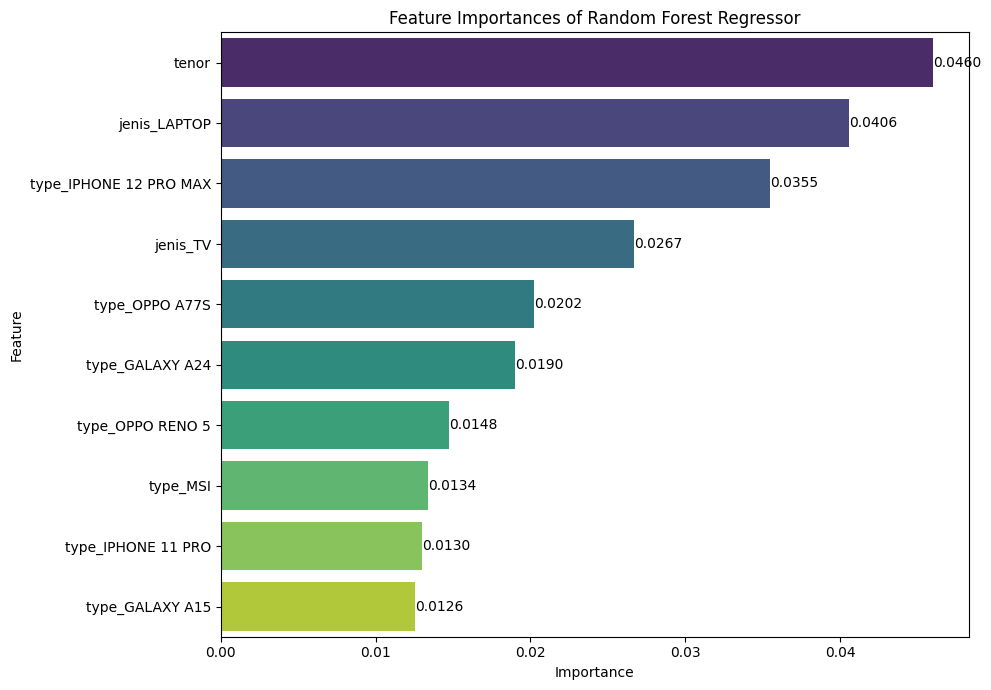

In [37]:
# feature importance
preprocessed_numerical_features = numerical_features

# col cat
preprocessed_categorical_features = pipeline.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_preprocessed_features = list(preprocessed_numerical_features) + list(preprocessed_categorical_features)
selected_features_mask = pipeline.named_steps['select'].get_support()
final_features = np.array(all_preprocessed_features)[selected_features_mask]
feature_importances = pipeline.named_steps['rf'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': feature_importances
})

# sort desc
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# top 10
importance_df = importance_df.nlargest(10, 'Importance')

# plot
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances of Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')

# add
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()